# 1. Introduction

This EDA notebook uses the raw-derived processed modeling dataset (`modeling_dataset_2015_2019.csv`). Summary-derived speed/heavy-vehicle features are intentionally excluded for Issue #4 alignment.

# 2. Data Overview

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate
    return start

repo_root = find_repo_root(Path.cwd())
data_path = repo_root / "data" / "processed" / "modeling_dataset_2015_2019.csv"

if not data_path.exists():
    raise FileNotFoundError(f"Missing {data_path}. Run notebooks/04_raw_preprocessing.ipynb first.")

df = pd.read_csv(data_path)
df["date"] = pd.to_datetime(df["date"], errors="coerce")

print(f"Loaded dataset: {data_path}")
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
print("Columns:", df.columns.tolist())


Loaded dataset: /Users/manavparikh/Documents/GitHub/unfc-capstone-traffic-forecasting/data/processed/modeling_dataset_2015_2019.csv
Dataset shape: 5778 rows x 12 columns
Columns: ['location_id', 'location_name', 'centreline_id', 'date', 'year', 'month', 'day_of_week', 'is_weekend', 'daily_total_volume', 'peak_hour_volume', 'peak_ratio', 'congestion_target']


In [2]:
df.head()

,location_id,location_name,centreline_id,date,year,month,day_of_week,is_weekend,daily_total_volume,peak_hour_volume,peak_ratio,congestion_target
0,10010625_WB,Danforth Ave: Donlands Ave - Byron Ave,10010625,2015-05-14,2015,5,3,0,17031,1809,0.106218,17031
1,10010625_WB,Danforth Ave: Donlands Ave - Byron Ave,10010625,2015-05-15,2015,5,4,0,17365,1734,0.099856,17365
2,10010625_WB,Danforth Ave: Donlands Ave - Byron Ave,10010625,2015-05-16,2015,5,5,1,14470,1066,0.073670,14470
3,10010625_WB,Danforth Ave: Donlands Ave - Byron Ave,10010625,2015-05-17,2015,5,6,1,12235,973,0.079526,12235
4,10010625_WB,Danforth Ave: Donlands Ave - Byron Ave,10010625,2015-05-18,2015,5,0,0,16523,1775,0.107426,16523


In [3]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
location_id,5778,914,103009_NB,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location_name,5778,711,Sewells Rd: Old Finch Ave - Steeles Ave E,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN
centreline_id,5778.0,NaN,NaN,NaN,10477128.899446,415.0,906778.0,7792640.5,14037408.0,60042531.0,12973711.664557
date,5778,NaN,NaN,NaN,2016-12-06 12:22:25.794392,2015-03-31 00:00:00,2015-06-04 06:00:00,2016-06-04 00:00:00,2018-06-02 00:00:00,2019-11-05 00:00:00,NaN
year,5778.0,NaN,NaN,NaN,2016.472655,2015.0,2015.0,2016.0,2018.0,2019.0,1.397479
month,5778.0,NaN,NaN,NaN,6.109034,1.0,5.0,6.0,8.0,12.0,2.895721
day_of_week,5778.0,NaN,NaN,NaN,2.674974,0.0,1.0,2.0,4.0,6.0,1.783097
is_weekend,5778.0,NaN,NaN,NaN,0.196435,0.0,0.0,0.0,0.0,1.0,0.397335
daily_total_volume,5778.0,NaN,NaN,NaN,10875.843891,0.0,7235.5,10792.5,14577.75,40994.0,5835.897287
peak_hour_volume,5778.0,NaN,NaN,NaN,929.765144,0.0,606.0,926.0,1230.0,3047.0,473.111636


# 3. Missing Values and Data Quality

In [4]:
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_counts[missing_counts > 0]

peak_ratio    1
dtype: int64

In [5]:
quality_flags = {
    "duplicate_rows": int(df.duplicated().sum()),
    "negative_daily_total_volume": int((df["daily_total_volume"] < 0).sum()) if "daily_total_volume" in df.columns else 0,
    "negative_peak_hour_volume": int((df["peak_hour_volume"] < 0).sum()) if "peak_hour_volume" in df.columns else 0,
    "invalid_peak_ratio_lt_0": int((df["peak_ratio"] < 0).sum()) if "peak_ratio" in df.columns else 0,
    "invalid_peak_ratio_gt_1": int((df["peak_ratio"] > 1).sum()) if "peak_ratio" in df.columns else 0,
    "negative_congestion_target": int((df["congestion_target"] < 0).sum()) if "congestion_target" in df.columns else 0,
}

pd.Series(quality_flags)


duplicate_rows                 0
negative_daily_total_volume    0
negative_peak_hour_volume      0
invalid_peak_ratio_lt_0        0
invalid_peak_ratio_gt_1        0
negative_congestion_target     0
dtype: int64

In [6]:
def iqr_outlier_count(series: pd.Series) -> int:
    x = series.dropna()
    if x.empty:
        return 0
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        return 0
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    return int(((x < lo) | (x > hi)).sum())

outlier_report = {
    c: iqr_outlier_count(df[c])
    for c in ["daily_total_volume", "peak_hour_volume", "peak_ratio", "congestion_target"]
    if c in df.columns
}

pd.Series(outlier_report, name="iqr_outlier_rows")


daily_total_volume     62
peak_hour_volume       65
peak_ratio            384
congestion_target      62
Name: iqr_outlier_rows, dtype: int64

# 4. Traffic Trends Over Time

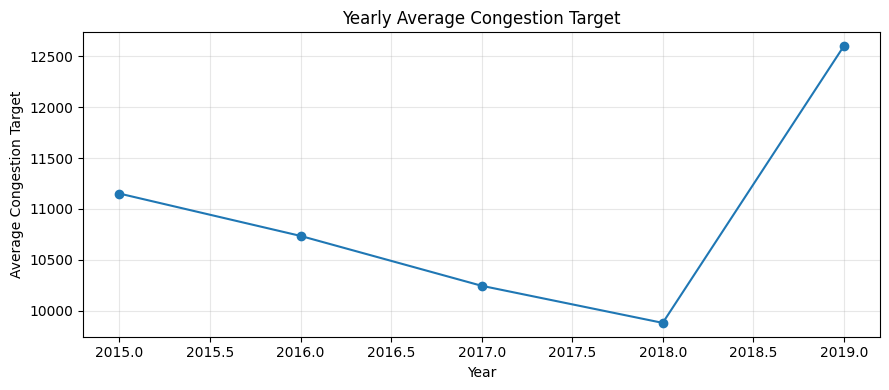

In [7]:
yearly = (
    df.dropna(subset=["date", "congestion_target"])
      .groupby(df["date"].dt.year, as_index=False)["congestion_target"]
      .mean()
)

plt.figure(figsize=(9, 4))
plt.plot(yearly["date"], yearly["congestion_target"], marker="o")
plt.title("Yearly Average Congestion Target")
plt.xlabel("Year")
plt.ylabel("Average Congestion Target")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


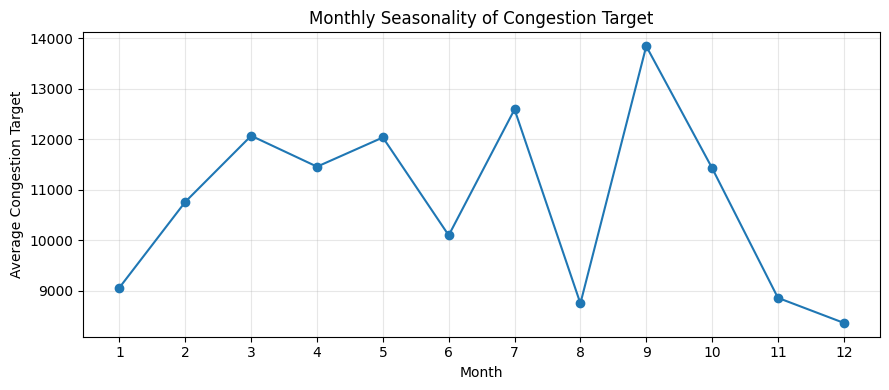

In [8]:
monthly = (
    df.dropna(subset=["date", "congestion_target"])
      .assign(month=df["date"].dt.month)
      .groupby("month", as_index=False)["congestion_target"]
      .mean()
)

plt.figure(figsize=(9, 4))
plt.plot(monthly["month"], monthly["congestion_target"], marker="o")
plt.xticks(range(1, 13))
plt.title("Monthly Seasonality of Congestion Target")
plt.xlabel("Month")
plt.ylabel("Average Congestion Target")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# 5. Weekly Seasonality

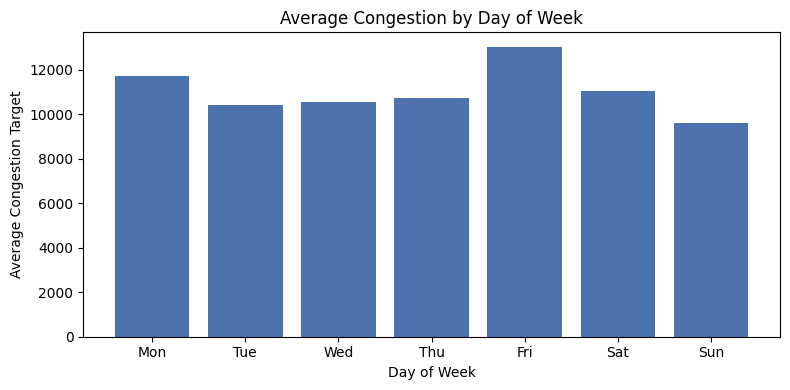

In [9]:
dow_src = df.dropna(subset=["day_of_week", "congestion_target"]).copy()
dow_src["day_of_week"] = pd.to_numeric(dow_src["day_of_week"], errors="coerce")

dow = (
    dow_src.dropna(subset=["day_of_week"])
    .groupby("day_of_week", as_index=False)
    .agg(congestion_target=("congestion_target", "mean"))
)
dow = dow.sort_values(by="day_of_week").reset_index(drop=True)

dow["day_of_week"] = dow["day_of_week"].astype(int)
name_map = {0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"}
dow["day_name"] = dow["day_of_week"].map(name_map)

plt.figure(figsize=(8, 4))
plt.bar(dow["day_name"], dow["congestion_target"], color="#4C72B0")
plt.title("Average Congestion by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Congestion Target")
plt.tight_layout()
plt.show()


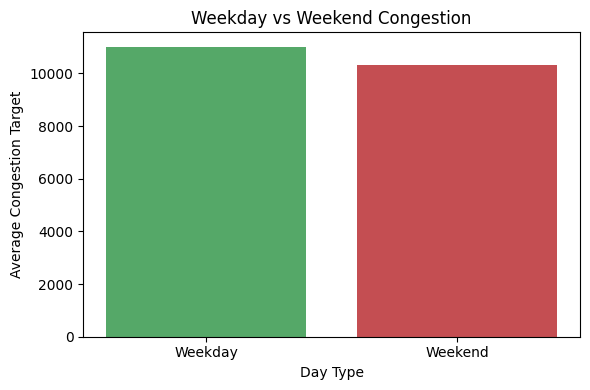

In [10]:
day_type = (
    df.dropna(subset=["is_weekend", "congestion_target"])
      .assign(day_type=np.where(df["is_weekend"] == 1, "Weekend", "Weekday"))
      .groupby("day_type", as_index=False)["congestion_target"]
      .mean()
)

order = ["Weekday", "Weekend"]
day_type = day_type.set_index("day_type").reindex(order).reset_index()

plt.figure(figsize=(6, 4))
plt.bar(day_type["day_type"], day_type["congestion_target"], color=["#55A868", "#C44E52"])
plt.title("Weekday vs Weekend Congestion")
plt.xlabel("Day Type")
plt.ylabel("Average Congestion Target")
plt.tight_layout()
plt.show()


# 6. Relationship and Distribution Checks

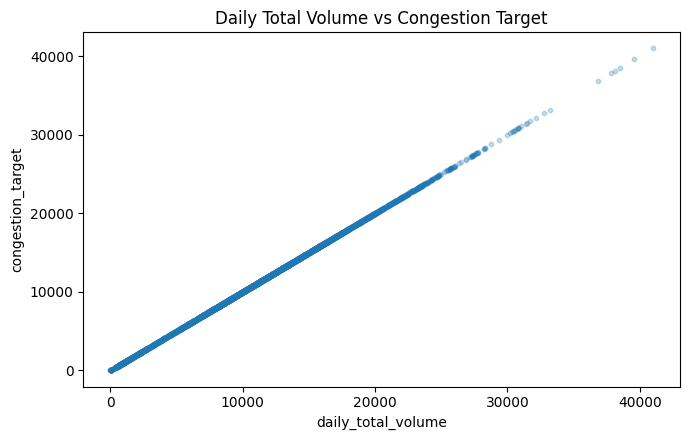

In [11]:
plt.figure(figsize=(7, 4.5))
valid = df.dropna(subset=["daily_total_volume", "congestion_target"])
plt.scatter(valid["daily_total_volume"], valid["congestion_target"], alpha=0.25, s=10)
plt.title("Daily Total Volume vs Congestion Target")
plt.xlabel("daily_total_volume")
plt.ylabel("congestion_target")
plt.tight_layout()
plt.show()


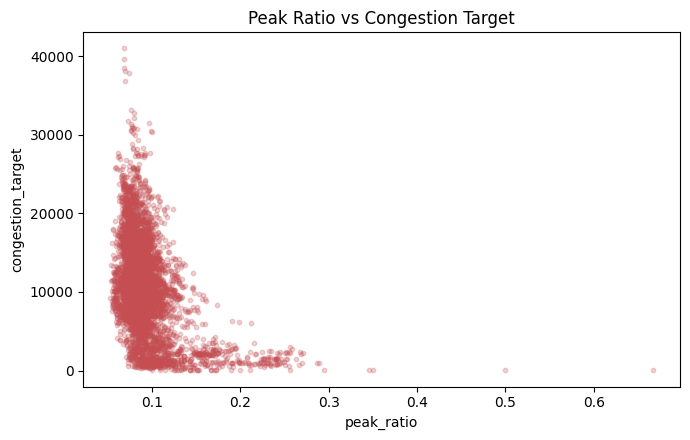

In [12]:
plt.figure(figsize=(7, 4.5))
valid = df.dropna(subset=["peak_ratio", "congestion_target"])
plt.scatter(valid["peak_ratio"], valid["congestion_target"], alpha=0.25, s=10, color="#C44E52")
plt.title("Peak Ratio vs Congestion Target")
plt.xlabel("peak_ratio")
plt.ylabel("congestion_target")
plt.tight_layout()
plt.show()


# 7. Correlation Matrix (Available Numeric Columns)

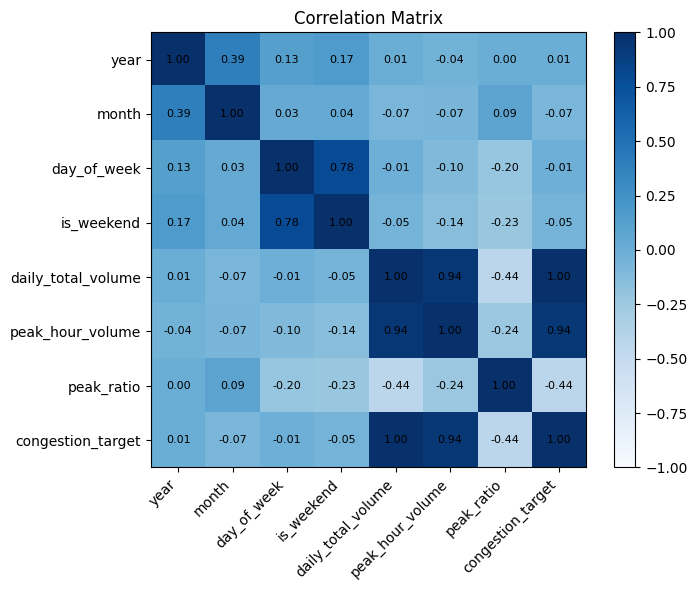

,year,month,day_of_week,is_weekend,daily_total_volume,peak_hour_volume,peak_ratio,congestion_target
year,1.000000,0.389652,0.129670,0.167884,0.007205,-0.041947,0.001758,0.007205
month,0.389652,1.000000,0.027482,0.040808,-0.073810,-0.070136,0.092643,-0.073810
day_of_week,0.129670,0.027482,1.000000,0.781568,-0.014105,-0.102850,-0.204883,-0.014105
is_weekend,0.167884,0.040808,0.781568,1.000000,-0.047107,-0.143661,-0.225340,-0.047107
daily_total_volume,0.007205,-0.073810,-0.014105,-0.047107,1.000000,0.940999,-0.435665,1.000000
peak_hour_volume,-0.041947,-0.070136,-0.102850,-0.143661,0.940999,1.000000,-0.241997,0.940999
peak_ratio,0.001758,0.092643,-0.204883,-0.225340,-0.435665,-0.241997,1.000000,-0.435665
congestion_target,0.007205,-0.073810,-0.014105,-0.047107,1.000000,0.940999,-0.435665,1.000000


In [13]:
corr_candidates = [
    "year",
    "month",
    "day_of_week",
    "is_weekend",
    "daily_total_volume",
    "peak_hour_volume",
    "peak_ratio",
    "congestion_target",
]

corr_cols = [c for c in corr_candidates if c in df.columns]
corr = df[corr_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr.values, cmap="Blues", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticks(range(len(corr_cols)))
ax.set_yticklabels(corr_cols)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=8)

ax.set_title("Correlation Matrix")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

corr


## Outputs

- Input used: `data/processed/modeling_dataset_2015_2019.csv`
- No new persisted dataset is required for this EDA notebook.